# 04 Statistics and experiment design

Notebooks 02 and 03 found gaps between segments. This one checks whether those gaps survive a significance test, whether they hold once the obvious confounders are controlled for, and how long an experiment would take to move them.

Everything here is observational, so a significant difference means the segments really do behave differently, not that the segment caused it. That is exactly why the last section turns each finding into a test rather than a recommendation.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from ga4_growth import metrics, stats, viz
from ga4_growth.warehouse import query

viz.setup()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

## Is the mobile payment gap real

Two proportion z tests against desktop, on sessions that reached the shipping info step. Holm correction is applied because three devices are compared at once and the chance of one of them looking significant by accident goes up with each extra comparison.

In [2]:
device = metrics.funnel_by("device_category", min_sessions=0)

payment_test = stats.compare_segments(
    device, label_col="segment", success_col="added_payment", total_col="added_shipping",
    baseline="desktop",
)
payment_test.round(4)

,label,baseline,rate_a,rate_b,absolute_diff,relative_lift,z_stat,p_value,ci_low,ci_high,p_adjusted,significant
0,mobile,desktop,0.8887,0.7937,-0.0950,-0.1069,-10.0060,0.0000,-0.1141,-0.0759,0.0000,True
1,tablet,desktop,0.8887,0.8568,-0.0319,-0.0359,-1.9022,0.0572,-0.0676,0.0038,0.0572,False


,device,reached_shipping,rate,ci_low,ci_high
0,mobile,2496,0.7937,0.7773,0.8091
1,desktop,3342,0.8887,0.8776,0.8989
2,tablet,405,0.8568,0.8193,0.8876


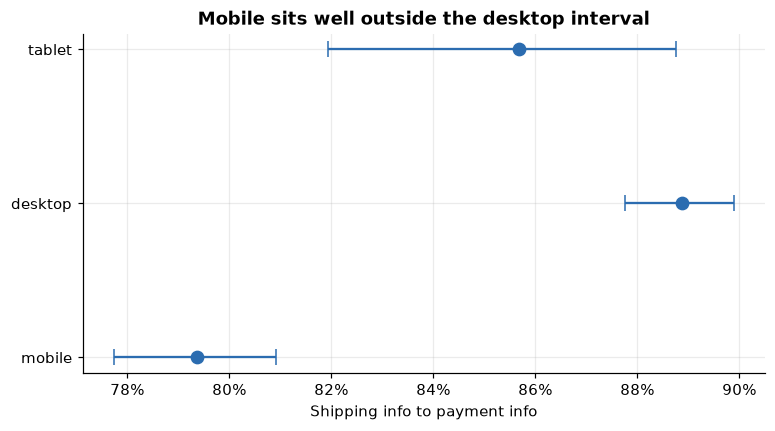

In [3]:
# Wilson intervals on the rate itself. Overlapping intervals would mean the
# difference is not worth acting on even if the p value is small.
rows = []
for _, r in device.iterrows():
    low, high = stats.wilson_ci(int(r["added_payment"]), int(r["added_shipping"]))
    rows.append({"device": r["segment"], "reached_shipping": int(r["added_shipping"]),
                 "rate": r["shipping_to_payment_rate"], "ci_low": low, "ci_high": high})
ci = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(ci["rate"], ci["device"],
            xerr=[ci["rate"] - ci["ci_low"], ci["ci_high"] - ci["rate"]],
            fmt="o", color=viz.PALETTE[0], capsize=5, ms=8)
ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_xlabel("Shipping info to payment info")
ax.set_title("Mobile sits well outside the desktop interval")
viz.save(fig, "04_payment_step_ci")
ci.round(4)

In [4]:
# Same test on the step above it. If mobile were simply worse everywhere the
# cart to checkout step would fail too, and it does not by nearly as much.
stats.compare_segments(
    device, label_col="segment", success_col="began_checkout", total_col="added_to_cart",
    baseline="desktop",
).round(4)

,label,baseline,rate_a,rate_b,absolute_diff,relative_lift,z_stat,p_value,ci_low,ci_high,p_adjusted,significant
0,mobile,desktop,0.4,0.3323,-0.0677,-0.1691,-9.8046,0.0000,-0.0811,-0.0542,0.0000,True
1,tablet,desktop,0.4,0.3484,-0.0516,-0.1291,-3.7538,0.0002,-0.0780,-0.0252,0.0002,True


## Channels against the site average

In [5]:
channel = metrics.funnel_by("channel_group", min_sessions=0)
stats.compare_segments(
    channel, label_col="segment", success_col="purchased", total_col="sessions",
).round(4)

,label,baseline,rate_a,rate_b,absolute_diff,relative_lift,z_stat,p_value,ci_low,ci_high,p_adjusted,significant
0,Referral,Paid,0.0166,0.0085,-0.0081,-0.4868,-7.8023,0.0000,-0.0097,-0.0064,0.0000,True
1,Affiliate,Paid,0.0166,0.0176,0.0011,0.0644,0.6780,0.4978,-0.0021,0.0042,0.4978,False
2,Organic Search,Paid,0.0166,0.0179,0.0013,0.0792,1.8665,0.0620,-0.0001,0.0027,0.1239,False
3,Direct,Paid,0.0166,0.0253,0.0087,0.5275,11.0807,0.0000,0.0071,0.0104,0.0000,True
4,Email,Paid,0.0166,0.0406,0.0240,1.4481,17.9683,0.0000,0.0205,0.0276,0.0000,True


In [6]:
# Split into top of funnel and bottom of funnel. Paid social fails on the first
# and is close to normal on the second, which says the traffic is the problem
# rather than the checkout.
top = stats.compare_segments(channel, "segment", "added_to_cart", "viewed_product")
bottom = stats.compare_segments(channel, "segment", "purchased", "began_checkout")

pd.merge(
    top[["label", "rate_b", "absolute_diff", "p_adjusted", "significant"]],
    bottom[["label", "rate_b", "absolute_diff", "p_adjusted", "significant"]],
    on="label", suffixes=("_view_to_cart", "_checkout_to_purchase"),
).round(4)

,label,rate_b_view_to_cart,absolute_diff_view_to_cart,p_adjusted_view_to_cart,significant_view_to_cart,rate_b_checkout_to_purchase,absolute_diff_checkout_to_purchase,p_adjusted_checkout_to_purchase,significant_checkout_to_purchase
0,Referral,0.0834,-0.0460,0.0,True,0.5714,-0.0102,1.0,False
1,Organic Search,0.1398,0.0104,0.0,True,0.5716,-0.0100,1.0,False
2,Affiliate,0.1851,0.0557,0.0,True,0.5670,-0.0146,1.0,False
3,Email,0.2219,0.0925,0.0,True,0.5993,0.0177,1.0,False


## Does device change where sessions give up

Chi square on device against the furthest step reached. It answers a different question from the step tests: not whether one rate differs, but whether the shape of the whole drop off pattern differs. Cramer's V is reported because with 228k sessions almost anything comes out significant.

In [7]:
table = query("""
SELECT device_category, furthest_step, count(*) AS sessions
FROM fct_funnel GROUP BY 1, 2
""").pivot(index="device_category", columns="furthest_step", values="sessions").fillna(0)

print(stats.chi_square(table))
(table.div(table.sum(axis=1), axis=0) * 100).round(2)

{'chi2': np.float64(566.2864261926607), 'p_value': np.float64(7.878392901805591e-112), 'dof': 14, 'cramers_v': np.float64(0.03522376236883557), 'n': 228210}


furthest_step,0,1,2,3,4,5,6,7
device_category,,,,,,,,
desktop,35.04,54.90,2.09,3.95,0.71,0.37,0.40,2.54
mobile,38.30,53.26,1.78,3.86,0.57,0.46,0.31,1.46
tablet,37.11,53.80,1.77,4.15,0.61,0.37,0.33,1.85


## Separating device from channel

Mobile carries more paid social traffic than desktop does, so part of the mobile gap could just be the traffic mix. A logistic regression on session purchase holds channel, user type, country and browsing depth fixed and reports what is left over for device.

This is used as a controlled comparison, not as a prediction model. There is no train and test split because nothing here is meant to score future sessions.

In [8]:
frame = metrics.session_model_frame()
frame["log_duration"] = np.log1p(frame["session_duration_sec"])
frame["log_price"] = np.log1p(frame["avg_viewed_price"])
print(frame.shape)
frame.head()

(144280, 14)


,purchased,added_to_cart,device_category,channel_group,user_type,country,day_part,primary_category,products_viewed,pageviews,session_duration_sec,avg_viewed_price,log_duration,log_price
0,0,0,desktop,Paid,New,Singapore,Night,Apparel,1,4,80,66.66,4.394449,4.214495
1,0,0,mobile,Organic Search,New,United States,Night,Accessories,1,5,105,28.09,4.663439,3.370394
2,0,0,desktop,Paid,New,United States,Morning,Apparel,1,5,108,19.77,4.691348,3.033510
3,0,0,desktop,Email,New,Germany,Morning,Apparel,2,4,82,58.89,4.418841,4.092510
4,0,0,mobile,Paid,New,France,Morning,Apparel,4,7,154,39.10,5.043425,3.691376


In [9]:
formula = (
    "purchased ~ C(device_category, Treatment('desktop'))"
    " + C(channel_group, Treatment('Direct'))"
    " + C(user_type, Treatment('New'))"
    " + log_price + products_viewed + log_duration"
)
model = smf.logit(formula, data=frame).fit(disp=False)

odds = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "ci_low": np.exp(model.conf_int()[0]),
    "ci_high": np.exp(model.conf_int()[1]),
    "p_value": model.pvalues,
}).drop(index="Intercept")
odds.index = (odds.index
              .str.replace(r"C\((\w+), Treatment\('[^']+'\)\)\[T\.", r"\1: ", regex=True)
              .str.replace("]", "", regex=False))
odds.round(4)

,odds_ratio,ci_low,ci_high,p_value
device_category: mobile,0.4672,0.4267,0.5115,0.0000
device_category: tablet,0.6789,0.5702,0.8082,0.0000
channel_group: Affiliate,0.6314,0.4918,0.8107,0.0003
channel_group: Email,1.2253,1.0502,1.4296,0.0098
channel_group: Organic Search,0.8098,0.7202,0.9106,0.0004
channel_group: Paid,0.9143,0.8174,1.0227,0.1170
channel_group: Referral,0.7623,0.6006,0.9675,0.0256
user_type: Returning,1.8178,1.6676,1.9815,0.0000
log_price,1.0297,0.9399,1.1281,0.5294
products_viewed,0.9585,0.9210,0.9975,0.0372


'reports\\figures\\04_logit_odds_ratios.png'

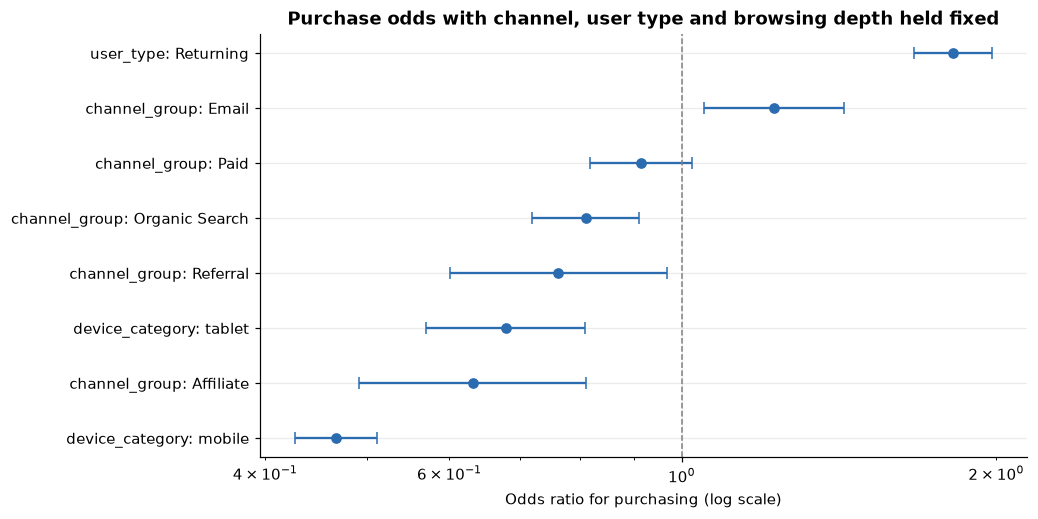

In [10]:
# Odds ratios on a log axis. Anything whose interval crosses 1 is not doing
# anything once the rest of the model is accounted for.
plot_rows = odds[odds.index.str.contains("device|channel|user_type")].sort_values("odds_ratio")

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(plot_rows["odds_ratio"], plot_rows.index,
            xerr=[plot_rows["odds_ratio"] - plot_rows["ci_low"],
                  plot_rows["ci_high"] - plot_rows["odds_ratio"]],
            fmt="o", color=viz.PALETTE[0], capsize=4)
ax.axvline(1, color="grey", ls="--", lw=1)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio for purchasing (log scale)")
ax.set_title("Purchase odds with channel, user type and browsing depth held fixed")
viz.save(fig, "04_logit_odds_ratios")

In [11]:
# Narrower version of the same idea, restricted to sessions that already reached
# the shipping step. At that point intent is roughly equal across segments, so
# what is left is the interface.
checkout = query("""
SELECT added_payment::INT AS added_payment, device_category, channel_group, user_type, log(avg_viewed_price + 1) AS log_price
FROM fct_funnel WHERE added_shipping
""")

checkout_model = smf.logit(
    "added_payment ~ C(device_category, Treatment('desktop')) + C(channel_group, Treatment('Direct'))"
    " + C(user_type, Treatment('New')) + log_price",
    data=checkout,
).fit(disp=False)

pd.DataFrame({
    "odds_ratio": np.exp(checkout_model.params),
    "p_value": checkout_model.pvalues,
}).round(4)

,odds_ratio,p_value
Intercept,5.6241,0.0000
"C(device_category, Treatment('desktop'))[T.mobile]",0.4772,0.0000
"C(device_category, Treatment('desktop'))[T.tablet]",0.7479,0.0569
"C(channel_group, Treatment('Direct'))[T.Affiliate]",0.9028,0.6259
"C(channel_group, Treatment('Direct'))[T.Email]",1.3150,0.0406
"C(channel_group, Treatment('Direct'))[T.Organic Search]",1.0447,0.6504
"C(channel_group, Treatment('Direct'))[T.Paid]",1.0687,0.4717
"C(channel_group, Treatment('Direct'))[T.Referral]",1.0645,0.7694
"C(user_type, Treatment('New'))[T.Returning]",1.4131,0.0000
log_price,1.0727,0.6864


## Order value

Order value has a long right tail, so a t test on the mean is the wrong tool. A percentile bootstrap gives an honest interval for the mean and Mann Whitney compares the middle of the two distributions.

In [12]:
orders = query("""
SELECT o.order_value, f.device_category
FROM fct_orders AS o JOIN fct_funnel AS f USING (session_id)
""")

boot = []
for dev, part in orders.groupby("device_category"):
    mean, low, high = stats.bootstrap_mean_ci(part["order_value"].to_numpy())
    boot.append({"device": dev, "orders": len(part), "mean_aov": mean,
                 "ci_low": low, "ci_high": high,
                 "median_aov": part["order_value"].median()})
pd.DataFrame(boot).round(2)

,device,orders,mean_aov,ci_low,ci_high,median_aov
0,desktop,2566,69.56,67.44,71.75,56.08
1,mobile,1632,69.63,66.94,72.23,56.18
2,tablet,294,69.27,62.84,75.93,56.04


In [13]:
stats.mann_whitney(
    orders.loc[orders["device_category"] == "desktop", "order_value"].to_numpy(),
    orders.loc[orders["device_category"] == "mobile", "order_value"].to_numpy(),
)

{'u_stat': 2082330.0,
 'p_value': 0.7633155840913367,
 'rank_biserial': 0.00550467653936082,
 'median_a': 56.08,
 'median_b': 56.18}

## How big does a test need to be

Two things decide this: the baseline rate of the metric being moved, and how much traffic reaches the step where the change is visible. Testing on a step deep in the funnel is a much better deal than testing on the whole session, because the baseline rate is far higher there.

In [14]:
grid = []
for metric_name, rate in [
    ("session conversion", metrics.headline_kpis()["session_conversion_rate"]),
    ("view to cart", metrics.headline_kpis()["view_to_cart_rate"]),
    ("cart to checkout", metrics.headline_kpis()["cart_to_checkout_rate"]),
    ("mobile shipping to payment", device.set_index("segment").loc["mobile", "shipping_to_payment_rate"]),
]:
    for mde in [0.03, 0.05, 0.10, 0.20]:
        grid.append({"metric": metric_name, "baseline": round(float(rate), 4),
                     "relative_mde": mde,
                     "n_per_arm": stats.sample_size_per_arm(float(rate), mde)})

pd.DataFrame(grid).pivot(index=["metric", "baseline"], columns="relative_mde", values="n_per_arm")

,relative_mde,0.03,0.05,0.10,0.20
metric,baseline,,,,
cart to checkout,0.3661,30387,10982,2771,703
mobile shipping to payment,0.7937,4334,1509,342,63
session conversion,0.0197,880641,320060,81892,21395
view to cart,0.1455,103700,37633,9593,2488


In [15]:
# Daily traffic at each step, which is what turns a sample size into a number of
# days. 91 days of history in the warehouse.
days = query("SELECT count(DISTINCT session_date) AS d FROM fct_funnel")["d"][0]
daily_volume = query(f"""
SELECT
  round(count(*) / {days})                                                          AS sessions_per_day,
  round(count(*) FILTER (WHERE viewed_product) / {days})                            AS product_view_sessions_per_day,
  round(count(*) FILTER (WHERE added_to_cart) / {days})                             AS cart_sessions_per_day,
  round(count(*) FILTER (WHERE added_shipping AND device_category = 'mobile') / {days}) AS mobile_shipping_per_day
FROM fct_funnel
""")
daily_volume

,sessions_per_day,product_view_sessions_per_day,cart_sessions_per_day,mobile_shipping_per_day
0,2508.0,1585.0,231.0,27.0


In [16]:
v = daily_volume.iloc[0]
kpi = metrics.headline_kpis()

plan = pd.DataFrame([
    stats.experiment_plan(
        "Mobile payment step redesign",
        baseline_rate=float(device.set_index("segment").loc["mobile", "shipping_to_payment_rate"]),
        daily_units_per_arm=v["mobile_shipping_per_day"] / 2,
        relative_mde=0.05,
    ),
    stats.experiment_plan(
        "Persistent cart summary and checkout entry",
        baseline_rate=float(kpi["cart_to_checkout_rate"]),
        daily_units_per_arm=v["cart_sessions_per_day"] / 2,
        relative_mde=0.08,
    ),
    stats.experiment_plan(
        "Product page trust and shipping cost block",
        baseline_rate=float(kpi["view_to_cart_rate"]),
        daily_units_per_arm=v["product_view_sessions_per_day"] / 2,
        relative_mde=0.05,
    ),
    stats.experiment_plan(
        "Paid social landing page matched to the ad",
        baseline_rate=float(kpi["session_conversion_rate"]),
        daily_units_per_arm=v["sessions_per_day"] * 0.16 / 2,
        relative_mde=0.20,
    ),
])
plan

,experiment,baseline_rate,relative_mde,n_per_arm,days_needed,power,alpha
0,Mobile payment step redesign,0.7937,0.05,1509,112,0.8,0.05
1,Persistent cart summary and checkout entry,0.3661,0.08,4314,38,0.8,0.05
2,Product page trust and shipping cost block,0.1455,0.05,37633,48,0.8,0.05
3,Paid social landing page matched to the ad,0.0197,0.20,21395,107,0.8,0.05


In [17]:
# The other direction: given a two week test, what is the smallest lift each of
# these could pick up. Anything above roughly 15% is not a realistic target for
# a checkout change.
two_weeks = []
for name, rate, per_day in [
    ("Mobile payment step", float(device.set_index("segment").loc["mobile", "shipping_to_payment_rate"]), v["mobile_shipping_per_day"] / 2),
    ("Cart to checkout", float(kpi["cart_to_checkout_rate"]), v["cart_sessions_per_day"] / 2),
    ("View to cart", float(kpi["view_to_cart_rate"]), v["product_view_sessions_per_day"] / 2),
    ("Session conversion, all traffic", float(kpi["session_conversion_rate"]), v["sessions_per_day"] / 2),
]:
    n = int(per_day * 14)
    two_weeks.append({"test": name, "n_per_arm_in_14_days": n,
                      "detectable_relative_lift": round(stats.detectable_lift(rate, n), 4)})
pd.DataFrame(two_weeks)

,test,n_per_arm_in_14_days,detectable_relative_lift
0,Mobile payment step,189,0.1297
1,Cart to checkout,1617,0.1312
2,View to cart,11095,0.0929
3,"Session conversion, all traffic",17556,0.2218


## What holds up

The mobile payment gap survives Holm correction, survives the regression that controls for channel and user type, and is backed by the time users spend on that step. That is the one finding strong enough to build a redesign around.

Paid social is a real difference too, but it shows up at the top of the funnel and not at checkout, so the fix is in targeting and landing pages rather than in the product.

Order value differences between devices are small and the intervals overlap, so mobile is a volume problem, not a basket size problem.

The full write up with recommended actions is in `docs/insights.md` and `docs/experiment_backlog.md`.